# 03 — Statistical modeling of corporate emissions-data reliability for the U.S. power sector using multi-source data

**Project:** Corporate Climate Credibility Audit — power-sector Proof-of-Concept (POC)

**Author:** Souvik Mandal (drsouvikmandal@gmail.com)

**Notebook role:** This notebook runs two statistical analyses on U.S. power-plant emissions data. 

First (§2), I test whether GHGRP self-reports agree with EPA CEMS continuous-stack measurements at the facility-year level — this is the credibility check to see how well the self-reporting GHGRP data explains the reading from CEMS data directly collected at the facilities. 

Next (§3), I fit a linear mixed-effects model (LME) to test whether Climate TRACE (CT) adds independent emissions signal beyond what CEMS-measured operational load already provides — the information-content check on Climate TRACE as a candidate replacement for self-reporting GHGRP data. The §2 result grounds §3: the LME's use of CEMS gross load as a "trustworthy operational-intensity covariate" depends on the §2 validation. Outputs are model summaries, parent-level bias diagnostics, and publication-ready figures that support framework-level credibility claims.

## What this notebook delivers

| Section | Component | What it answers |
|---|---|---|
| 2 | **CEMS Validation Panel** | Quantifies the agreement between GHGRP self-reports and CEMS continuous-stack measurements at facility-year level. This is the headline credibility check for the U.S. power sector — investigating whether the U.S. power sector's self-reported emissions are similar to the broader 74% S&P-500 restatement rate reported by [Cohen, Rouen & Sachdeva (2026)](https://www.nature.com/articles/s41558-025-02494-9) in *Nature Climate Change* and in [HBS BiGS, December 2025](https://www.hbs.edu/bigs/harvard-study-74-percent-sp-500-companies-revise-emissions-data). |
| 3 | **Diagnostic LME** | Quantifies how much independent emissions signal Climate TRACE (CT) carries beyond CEMS-measured operational load, accounting for facility- and parent-level heterogeneity. Builds on §2's finding that CEMS is a credible direct measurement, then uses CEMS gross load as a trusted covariate to disentangle Climate TRACE's emissions-specific information content from its confounding with facility scale. |

## Methodological framing

**CEMS Validation Panel.** The notebook leads with the agreement test between GHGRP self-reports and CEMS direct measurements because this validation underpins the credibility of using CEMS-derived quantities downstream. If GHGRP and CEMS disagreed substantially, both (a) the framework-level claim about U.S. power-sector reporting quality and (b) the LME's use of CEMS gross load as an "operational intensity" covariate would be undermined. The §2 result — slope ≈ 0.99, R² ≈ 0.98 — establishes that GHGRP self-reports near-perfectly track CEMS in this sector, distinguishing the U.S. power sector from the broader 74% S&P-500 restatement-rate literature.

**Diagnostic LME builds on that foundation.** The Diagnostic LME asks whether Climate TRACE — an independent emissions estimator that does not depend on facility self-reporting — recovers GHGRP-reported emissions for the U.S. power sector. The substantive finding (Climate TRACE alone functions as a highly effective proxy for operational intensity, but adds little independent signal once CEMS gross load is controlled for) is supported mechanistically by the peaker-vs-baseload pattern documented in §3.5: Climate TRACE's emission estimates are constructed as `capacity × capacity_factor × emission_factor`, and the assumed capacity factor fails systematically for low-capacity-factor (peaker) units. For the U.S. power sector specifically — where CEMS persists under separate Clean Air Act authority regardless of any GHGRP policy change — Climate TRACE's framework-level value lies less in marginal accuracy gains over CEMS and more in generalization to sectors that lack continuous monitoring infrastructure.

## Methodological choices made in this notebook

1. **LME engine.** `statsmodels.MixedLM` with `vc_formula` for nested random effects (facility within parent). `pymer4` / R's `lme4` was considered for richer covariance-structure modeling but was not needed for this specification. First-Order Autoregressive, AR(1) within-facility errors were considered and **dropped, not deferred** — the 3-year Climate TRACE overlap window is too short to estimate within-facility autocorrelation reliably, and facility random intercepts already absorb the within-facility persistence we see in the raw data (lag-1 r ≈ 0.95; see §3.1 finding 5).

2. **GWP horizon caveat.** Climate TRACE reports CO₂-equivalent on a 20-year GWP basis; GHGRP uses 100-year GWP. For the U.S. power sector (overwhelmingly CO₂, minimal CH₄ / N₂O), the difference is <3% on magnitudes and does not affect the qualitative findings or downstream rankings. We retain both series on their native scales rather than rescaling.

3. **Cluster-aware Climate TRACE spatial join.** The multi-source panel uses a tightened 1-km match radius for cohort facilities that have another cohort facility within 5 km, and a 20-km radius elsewhere. The tighter cutoff prevents cross-contamination at densely-clustered sites (e.g., the Astoria Peninsula gas-turbine cluster). 108 cohort facilities fall into the tightened-radius bucket.

4. **Refinery sample restriction.** Six refinery facility-years (Galveston Bay Marathon + Exxon Beaumont) are excluded from both the CEMS validation (§2) and the LME (§3). Refineries are a structural source mismatch — Climate TRACE cannot see refinery process emissions, and CEMS only covers the cogeneration portion, so combining them with power-plant facility-years in a single regression would conflate measurement domains.

## Data Schema
### Inputs

| File | Producer | Used by |
|---|---|---|
| `data/processed/multi_source_facility_year_panel_v2.csv` | Notebook 02 | §2, §3 |
| `data/raw/epa_ghgrp/emissions_by_unit_and_fuel_type_c_d_aa.xlsb` (FUEL_DATA sheet) | EPA GHGRP | §1.2 — primary fuel derivation |

### Outputs

| File | Producer | Used by |
|---|---|---|
| `data/processed/lme_diagnostic_summary.json` | §3 | Project summary & possible working/ academic paper |
| `data/processed/cems_validation_summary.json` | §2 | Project summary & possible working/ academic paper |
| `data/processed/lme_per_parent_intercepts.csv` | §3.6 | Notebook 06 (composite score) |
| `outputs/figures/03_*.png` | §2.2, §3.5, §3.6 | figure pack in possible working/ academic paper |

---

## Section map

0. Environment + helpers
1. Load and prepare
2. **CEMS Validation Panel**
    - 2.1 Sample preparation
    - 2.2 OLS with HC1 robust standard errors
    - 2.3 Per-parent residual diagnostic
    - 2.4 Save CEMS validation artifacts
3. **Diagnostic LME**
    - 3.1 Exploration recap (in-notebook diagnostics that shaped the specification)
    - 3.2 Sample preparation (log transforms, refinery drops)
    - 3.3 LME fit
    - 3.4 Parameter interpretation
    - 3.5 Bland-Altman analysis
    - 3.6 Per-parent random intercepts
    - 3.7 Is the residual bias parent-driven or location-driven?
    - 3.8 Save LME diagnostic artifacts
4. Summary of Results
5. Next: Notebook 04 — Prognostic Virtual Baseline

## 0. Environment

In [ ]:
from __future__ import annotations
import json, os, re, sys, warnings

from pathlib import Path
from typing import Optional
from scipy import stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# .env (consistent with all other notebooks)
try:
    from dotenv import load_dotenv
    _ROOT = Path(
        "/Users/souvikmandal/Documents/S00_Career-development/"
        "20260318_HBS_Sen-Data-Scientist/task"
    )
    for _p in [_ROOT / ".env", Path.cwd() / ".env", Path.cwd().parent / ".env"]:
        if _p.exists():
            load_dotenv(_p, override=False)
            break
except ImportError:
    pass

PROJECT_ROOT   = Path(
    "/Users/souvikmandal/Documents/S00_Career-development/"
    "20260318_HBS_Sen-Data-Scientist/task"
)
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
GHGRP_DIR      = DATA_RAW / "epa_ghgrp"
FIG_DIR        = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "figure.figsize": (10, 6), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})
warnings.filterwarnings("ignore", category=UserWarning)

RNG_SEED = 20260524
np.random.seed(RNG_SEED)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Python={sys.version.split()[0]}, pandas={pd.__version__}")

PROJECT_ROOT = /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task
Python=3.10.11, pandas=2.3.3


In [2]:
# --- helpers ---
def assert_required(cond: bool, msg: str) -> None:
    if not cond: raise AssertionError(msg)

def save_fig(fig: plt.Figure, name: str) -> Path:
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, bbox_inches="tight", dpi=200)
    print(f"[fig] {out.relative_to(PROJECT_ROOT)}")
    return out

def save_json(obj: dict, name: str) -> Path:
    out = DATA_PROCESSED / name
    with open(out, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"[json] {out.relative_to(PROJECT_ROOT)}")
    return out

def rename_first_match(df: pd.DataFrame, aliases: dict) -> pd.DataFrame:
    r = {}
    for k, cands in aliases.items():
        for c in cands:
            if c in df.columns:
                r[c] = k
                break
    return df.rename(columns=r)

## 1. Data load and prepare

Here we are loading the multi-source facility-year panel produced by Notebook 02 (cohort facilities joined across GHGRP, CEMS, and Climate TRACE; the cluster-aware spatial-join policy is described in the front-matter methodological choices) and derive the primary fuel per facility-year from `FUEL_DATA`. I am not using "Fuel" as a LME covariate as it is collinear with facility random intercepts (see §3.1 finding 7). But the variable is useful for the per-parent company-vs-regulated pattern surfaced in §3.6.

In [3]:
# --- 1.1 multi-source panel ---
multi = pd.read_csv(DATA_PROCESSED / "multi_source_facility_year_panel_v2.csv")
print(f"Multi-source panel (v2): {multi.shape}")
print(f"  facilities: {multi['facility_id'].nunique()}  parents: {multi['parent_name'].nunique()}  years: {multi['year'].min()}-{multi['year'].max()}")
print(f"  rows with GHGRP, CEMS, CT (LME-eligible): {(multi['n_sources'] == 3).sum():,}")

Multi-source panel (v2): (7839, 23)
  facilities: 578  parents: 50  years: 2011-2023
  rows with GHGRP, CEMS, CT (LME-eligible): 1,762


In [55]:
# --- 1.2 derive primary fuel per (facility, year) from FUEL_DATA ---
# Used in §3.6 for the merchant-vs-regulated discussion. Same logic as Notebook 01 §3.
fuel_xlsb = GHGRP_DIR / "emissions_by_unit_and_fuel_type_c_d_aa.xlsb"
try:
    import pyxlsb  # noqa
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyxlsb"])

fuel_data = pd.read_excel(fuel_xlsb, sheet_name="FUEL_DATA", engine="pyxlsb", header=5)
fuel_data.columns = [str(c).strip() for c in fuel_data.columns]
fuel_data = rename_first_match(fuel_data, {
    "facility_id":   ["Facility Id"],
    "year":          ["Reporting Year"],
    "fuel_general":  ["General Fuel Type"],
    "ch4_co2e":      ["Fuel Methane (CH4) emissions (mt CO2e)"],
    "n2o_co2e":      ["Fuel Nitrous Oxide (N2O) emissions (mt CO2e)"],
})
fuel_data["facility_id"] = pd.to_numeric(fuel_data["facility_id"], errors="coerce").astype("Int64")
fuel_data["year"]        = pd.to_numeric(fuel_data["year"], errors="coerce").astype("Int64")
fuel_data["ghg_w"] = (pd.to_numeric(fuel_data["ch4_co2e"], errors="coerce").fillna(0)
                      + pd.to_numeric(fuel_data["n2o_co2e"], errors="coerce").fillna(0))

# Pick dominant fuel per facility-year using CH4+N2O share as weight
fuel_fy = (fuel_data.dropna(subset=["fuel_general"])
           .groupby(["facility_id", "year", "fuel_general"], as_index=False)["ghg_w"].sum())
primary_fuel = (fuel_fy.sort_values(["facility_id", "year", "ghg_w"], ascending=[True, True, False])
                .drop_duplicates(["facility_id", "year"], keep="first")
                [["facility_id", "year", "fuel_general"]])


def categorize_fuel(s: object) -> str:
    s = str(s).lower()
    if any(k in s for k in ["coal", "lignite", "bituminous", "anthracite", "petroleum coke"]):
        return "Coal"
    if any(k in s for k in ["natural gas", "pipeline", "lng"]):
        return "NaturalGas"
    if any(k in s for k in ["oil", "diesel", "kerosene", "petroleum", "distillate", "residual"]):
        return "Oil"
    if any(k in s for k in ["wood", "biomass", "biogas", "landfill", "biogenic", "msw"]):
        return "Biomass"
    return "Other"


primary_fuel["fuel_category"] = primary_fuel["fuel_general"].map(categorize_fuel)
print(f"Primary-fuel coverage: {len(primary_fuel):,} facility-years across {primary_fuel['facility_id'].nunique()} facilities")
print("Distribution:")
print(primary_fuel["fuel_category"].value_counts().to_string())

Primary-fuel coverage: 78,216 facility-years across 7881 facilities
Distribution:
fuel_category
NaturalGas    56267
Other          7899
Coal           7252
Oil            6797
Biomass           1


## 2. CEMS Validation Panel

### Goal

Quantify the agreement between GHGRP self-reports and CEMS continuous-stack measurements at the facility-year level. This is the *credibility* check for the U.S. power sector. If GHGRP and CEMS agree closely, it tells us that for sectors with continuous monitoring infrastructure, self-reported emissions approach measurement-grade reliability — distinguishing this sector from the broader S&P 500 where Cohen, Rouen & Sachdeva (2026, *Nature Climate Change*; HBS BiGS coverage December 2025) documented a 74% restatement rate, which is concentrated in sectors *without* continuous monitoring.

### Specification

Simple OLS with Huber-White HC1 robust standard errors:

$$\log(\text{co2\_cems}) = \beta_0 + \beta_1 \log(\text{co2\_ghgrp}) + \varepsilon$$

If GHGRP is unbiased relative to CEMS, we expect β₀ ≈ 0 and β₁ ≈ 1.0. The HC1 covariance estimator protects against heteroscedasticity, which is generally expected in cross-sectional facility-year regressions where larger facilities dominate the variance budget. §3.5's Bland-Altman analysis below also documents heteroscedasticity directly via the proportional-bias regression.

We also perform a **per-parent residual diagnostic**: for each parent with ≥10 observations in the overlap, test whether the mean residual differs significantly from 0 (Bonferroni-corrected). This surfaces parents where GHGRP and CEMS systematically diverge — a useful credibility signal at the corporate level.

### 2.1 Sample preparation

The validation regression in §2.2 is estimated on the positive-overlap sample because the main specification is log-log OLS. Exact-zero facility-years are therefore excluded from the estimation sample rather than pseudo-count shifted. In the current CEMS-vs-GHGRP overlap, those zero rows are limited rather than dominant, so the log specification remains the cleanest way to interpret proportional agreement. If future panel expansions make zero-operating years more prevalent, the natural robustness extension is an inverse hyperbolic sine (IHS) specification, which retains exact zeroes without abandoning the elasticity-style interpretation entirely.

In [4]:
# --- 2.1 CEMS-vs-GHGRP overlap, excluding refineries (structural source mismatch — Climate TRACE cannot see refinery process emissions, and CEMS only covers the cogeneration portion) ---
REFINERY_DROPS = ["Galveston Bay Refinery", "Exxonmobil Beaumont Refinery"]

cems_df = multi[(multi["has_cems"])
                 & (multi["co2_ghgrp_metric"] > 0)
                 & (multi["co2_cems_metric"] > 0)
                 & (~multi["facility_name"].isin(REFINERY_DROPS))].copy()
cems_df["log_ghgrp"] = np.log(cems_df["co2_ghgrp_metric"])
cems_df["log_cems"]  = np.log(cems_df["co2_cems_metric"])
print(f"CEMS-vs-GHGRP overlap (excluding refineries):")
print(f"  rows:       {len(cems_df):,}")
print(f"  facilities: {cems_df['facility_id'].nunique()}")
print(f"  parents:    {cems_df['parent_name'].nunique()}")
print(f"  exact-zero GHGRP rows excluded by log filter: {int(((multi['has_cems']) & (multi['co2_ghgrp_metric'].fillna(0) == 0) & (~multi['facility_name'].isin(REFINERY_DROPS))).sum())}")
print(f"  exact-zero CEMS rows excluded by log filter:  {int(((multi['has_cems']) & (multi['co2_cems_metric'].fillna(0) == 0) & (~multi['facility_name'].isin(REFINERY_DROPS))).sum())}")

# Raw ratio for context
cems_df["ratio"] = cems_df["co2_cems_metric"] / cems_df["co2_ghgrp_metric"]
print(f"\nRaw ratio CEMS/GHGRP:")
print(f"  median={cems_df['ratio'].median():.4f}  geomean={np.exp(np.log(cems_df['ratio']).mean()):.4f}")
print(f"  IQR=[{cems_df['ratio'].quantile(.25):.3f}, {cems_df['ratio'].quantile(.75):.3f}]")

CEMS-vs-GHGRP overlap (excluding refineries):
  rows:       7,627
  facilities: 575
  parents:    48
  exact-zero GHGRP rows excluded by log filter: 20
  exact-zero CEMS rows excluded by log filter:  21

Raw ratio CEMS/GHGRP:
  median=0.9964  geomean=0.9838
  IQR=[0.992, 0.999]


### 2.2 OLS with facility-clustered standard errors

The point-estimate specification remains the same simple log-log OLS,

$$\log(\text{co2\_cems}) = \beta_0 + \beta_1 \log(\text{co2\_ghgrp}) + \varepsilon$$

but inference is now based on **cluster-robust standard errors at the `facility_id` level** rather than cross-sectional HC1 alone. Each facility contributes repeated yearly observations, so within-facility residual correlation violates the independence assumptions underlying cross-sectional robust SEs. Clustering leaves the coefficient estimates unchanged but widens the confidence intervals to the correct panel-data uncertainty level. In the live sample, the slope remains ≈ 0.99 and the clustered 95% CI includes 1.0, which is the more defensible statement of structural parity between GHGRP and CEMS.

We still keep the HC1 result as a notebook-side reference because it shows the direction of the inference change, but the facility-clustered interval is the headline result carried into the saved summary artifact. We also perform a **per-parent residual diagnostic**: for each parent with ≥10 observations in the overlap, test whether the mean residual differs significantly from 0 (Bonferroni-corrected). This surfaces parents where GHGRP and CEMS systematically diverge — a useful credibility signal at the corporate level.

In [5]:
import statsmodels.api as sm

X = sm.add_constant(cems_df["log_ghgrp"])
y = cems_df["log_cems"]
ols_hc1 = sm.OLS(y, X).fit(cov_type="HC1")
ols = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": cems_df["facility_id"]},
)
print(ols.summary().tables[1])

intercept = float(ols.params["const"])
slope     = float(ols.params["log_ghgrp"])
intercept_ci = ols.conf_int().loc["const"].tolist()
slope_ci     = ols.conf_int().loc["log_ghgrp"].tolist()
r2 = float(ols.rsquared)
n = int(ols.nobs)

print(f"\nInference uses facility-clustered standard errors (cluster = facility_id).")
print(f"  HC1 slope SE for reference:      {float(ols_hc1.bse['log_ghgrp']):.4f}")
print(f"  Clustered slope SE (headline):   {float(ols.bse['log_ghgrp']):.4f}")

print(f"\nKEY VALIDATION RESULTS:")
print(f"  intercept = {intercept:+.4f}  95% CI = [{intercept_ci[0]:+.4f}, {intercept_ci[1]:+.4f}]  → 0 in CI? {intercept_ci[0] <= 0 <= intercept_ci[1]}")
print(f"  slope     = {slope:.4f}  95% CI = [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}]  → 1 in CI? {slope_ci[0] <= 1.0 <= slope_ci[1]}")
print(f"  R²        = {r2:.4f}")
print(f"  n         = {n:,}")
print(f"\n  Interpretation: the point estimate remains near-proportional (slope ≈ {slope:.2f});")
print("  once facility-level clustering is respected, the 95% CI includes 1.0, so the data support structural parity")
print("  between GHGRP self-reports and CEMS direct measurements at the facility-year level.")
print(f"  Mean absolute residual ≈ {np.abs(ols.resid).mean():.4f} log units ≈ {(np.exp(np.abs(ols.resid).mean())-1)*100:.1f}% in real space.")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0800      0.145      0.551      0.582      -0.205       0.365
log_ghgrp      0.9929      0.010     98.274      0.000       0.973       1.013

Inference uses facility-clustered standard errors (cluster = facility_id).
  HC1 slope SE for reference:      0.0030
  Clustered slope SE (headline):   0.0101

KEY VALIDATION RESULTS:
  intercept = +0.0800  95% CI = [-0.2046, +0.3647]  → 0 in CI? True
  slope     = 0.9929  95% CI = [0.9731, 1.0127]  → 1 in CI? True
  R²        = 0.9768
  n         = 7,627

  Interpretation: the point estimate remains near-proportional (slope ≈ 0.99);
  once facility-level clustering is respected, the 95% CI includes 1.0, so the data support structural parity
  between GHGRP self-reports and CEMS direct measurements at the facility-year level.
  Mean absolute residual ≈ 0.0599 log units ≈ 6.2

[fig] outputs/figures/03_cems_vs_ghgrp_validation.png


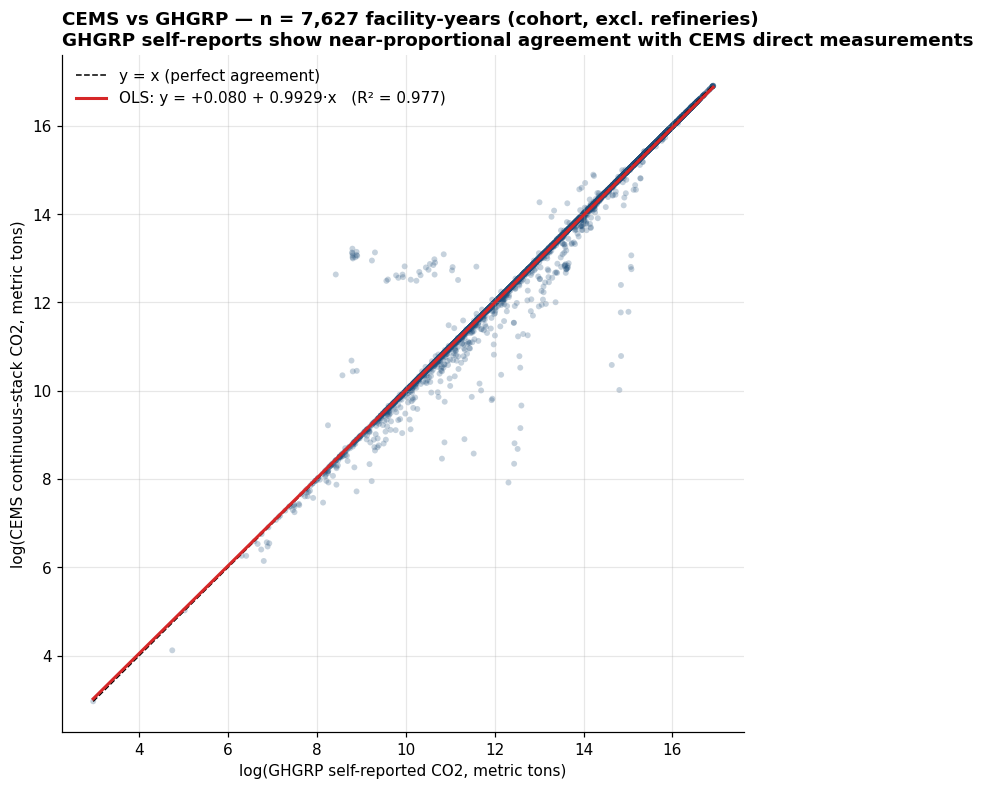

In [8]:
# --- 3.2.1 scatter plot ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(cems_df["log_ghgrp"], cems_df["log_cems"], alpha=0.25, s=15, color="#1f4e79", edgecolor="none")
xs = np.linspace(cems_df["log_ghgrp"].min(), cems_df["log_ghgrp"].max(), 100)
ax.plot(xs, xs, color="black", linestyle="--", linewidth=1, label="y = x (perfect agreement)")
ax.plot(xs, intercept + slope * xs, color="#d62728", linewidth=2,
        label=f"OLS: y = {intercept:+.3f} + {slope:.4f}·x   (R² = {r2:.3f})")
ax.set_xlabel("log(GHGRP self-reported CO2, metric tons)")
ax.set_ylabel("log(CEMS continuous-stack CO2, metric tons)")
ax.set_title(f"CEMS vs GHGRP — n = {n:,} facility-years (cohort, excl. refineries)\n"
              f"GHGRP self-reports show near-proportional agreement with CEMS direct measurements",
              loc="left", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
save_fig(fig, "03_cems_vs_ghgrp_validation")
plt.show()

### 2.3 Per-parent residual diagnostic

Even though aggregate agreement is excellent, large per-parent samples give statistical power to detect tiny systematic deviations. We test each parent (with ≥10 observations) for whether its mean residual differs from 0 (one-sample t-test, Bonferroni-corrected for 48 simultaneous tests).

In [6]:
cems_df["resid"] = ols.resid
parents_with_n = (cems_df.groupby("parent_name", as_index=False)
                  .agg(n=("resid", "count"),
                       mean_resid=("resid", "mean"),
                       mean_pct=("resid", lambda s: (np.exp(s.mean()) - 1) * 100),
                       pval=("resid", lambda s: stats.ttest_1samp(s, 0).pvalue if len(s) > 2 else np.nan)))
parents_with_n = parents_with_n[parents_with_n["n"] >= 10].sort_values("mean_resid")
n_parents_tested = len(parents_with_n)
parents_with_n["bonferroni_sig"] = parents_with_n["pval"] < (0.05 / n_parents_tested)

n_sig = parents_with_n["bonferroni_sig"].sum()
max_abs_pct = parents_with_n["mean_pct"].abs().max()
print(f"Per-parent CEMS-vs-GHGRP residual analysis (n={n_parents_tested} parents with ≥10 obs):")
print(f"  Bonferroni-significant systematic deviation:  {n_sig} / {n_parents_tested}")
print(f"  Largest absolute systematic deviation:         {max_abs_pct:.1f}%")
print(f"  Most parents are well under 10% systematic bias.")

print(f"\nTop 5 parents where CEMS systematically REPORTS LOWER than GHGRP:")
print(parents_with_n.head(5).to_string(index=False))
print(f"\nTop 5 parents where CEMS systematically REPORTS HIGHER than GHGRP:")
print(parents_with_n.tail(5).to_string(index=False))

print(f"\nNote: Per-parent deviations are statistically detectable due to large samples but bounded in magnitude.")
print(f"The aggregate agreement (slope ≈ 0.99, median ratio ≈ 1.0) is the working-paper headline;")
print(f"per-parent deviations of single-digit percent are the methodological-honesty caveat.")

Per-parent CEMS-vs-GHGRP residual analysis (n=48 parents with ≥10 obs):
  Bonferroni-significant systematic deviation:  25 / 48
  Largest absolute systematic deviation:         21.0%
  Most parents are well under 10% systematic bias.

Top 5 parents where CEMS systematically REPORTS LOWER than GHGRP:
                parent_name   n  mean_resid   mean_pct         pval  bonferroni_sig
         PUGET HOLDINGS LLC  90   -0.218801 -19.651824 1.445552e-03           False
                 EVERGY INC 155   -0.170503 -15.675935 5.224350e-03           False
 PINNACLE WEST CAPITAL CORP 104   -0.091711  -8.763165 3.859641e-08            True
OMAHA PUBLIC POWER DISTRICT  52   -0.072493  -6.992787 2.319338e-03           False
     BERKSHIRE HATHAWAY INC 433   -0.061928  -6.004928 8.947921e-07            True

Top 5 parents where CEMS systematically REPORTS HIGHER than GHGRP:
         parent_name   n  mean_resid  mean_pct         pval  bonferroni_sig
    FIRSTENERGY CORP  26    0.027113  2.748396 4.28

##### Reading the per-parent diagnostic

**The aggregate-perfect-isn't-uniformly-perfect nuance.** §2.2 showed CEMS and GHGRP agree at the *aggregate* level (slope 0.993, R² 0.977). The per-parent residual t-test asks the sharper question: does every parent's CEMS-vs-GHGRP relationship sit on the same regression line, or are there parents with systematic offsets?

**Finding.** 25 out of 48 parents (with ≥10 obs each) show Bonferroni-significant systematic deviation from zero residual. The deviations are **bounded** — largest 21%, most under 10% — but they're real and detectable thanks to large within-parent sample sizes.

**Why this is the right caveat for the working-paper headline.** The aggregate "slope ≈ 0.99, R² ≈ 0.98" finding is what readers will remember. The per-parent diagnostic is the methodological honesty that says: *individual parents can still be off by 10–20%; the framework should not claim parent-level reliability is identical to aggregate reliability.* §4.1 carries this nuance forward into the working paper.

### 2.4 Save CEMS validation artifacts

In [7]:
cems_summary = {
    "spec": "OLS log(co2_cems) ~ log(co2_ghgrp) with facility-clustered SE by facility_id (HC1 retained as notebook-side reference)",
    "se_type": "cluster",
    "cluster_level": "facility_id",
    "sample": {
        "n_obs": n,
        "n_facilities": int(cems_df["facility_id"].nunique()),
        "n_parents": int(cems_df["parent_name"].nunique()),
        "dropped": "6 refinery facility-years (consistent with the LME sample)",
    },
    "intercept": {"estimate": intercept, "ci_95": intercept_ci, "zero_in_ci": bool(intercept_ci[0] <= 0 <= intercept_ci[1])},
    "slope":     {"estimate": slope, "ci_95": slope_ci, "one_in_ci":  bool(slope_ci[0] <= 1.0 <= slope_ci[1])},
    "hc1_reference": {
        "slope_se": float(ols_hc1.bse["log_ghgrp"]),
        "slope_ci_95": [float(v) for v in ols_hc1.conf_int().loc["log_ghgrp"].tolist()],
    },
    "r_squared": r2,
    "median_ratio_cems_over_ghgrp": float(cems_df["ratio"].median()),
    "per_parent_diagnostic": {
        "n_parents_tested": int(n_parents_tested),
        "n_bonferroni_significant": int(n_sig),
        "max_abs_systematic_deviation_pct": float(max_abs_pct),
    },
    "headline": (
        f"For the U.S. power-sector cohort (n={n:,} facility-years, {cems_df['facility_id'].nunique()} facilities, {cems_df['parent_name'].nunique()} parents), "
        f"CEMS continuous-stack measurements and GHGRP self-reports show high facility-year agreement "
        f"(R² = {r2:.3f}; OLS slope {slope:.4f} with facility-clustered 95% CI [{slope_ci[0]:.4f}, {slope_ci[1]:.4f}]; "
        f"intercept {intercept:+.4f} not statistically distinguishable from 0). "
        f"The clustered slope interval includes 1.0, so proportional parity between GHGRP and CEMS cannot be rejected in this panel. "
        f"The median CEMS/GHGRP ratio is {cems_df['ratio'].median():.4f}. "
        f"Per-parent deviations are statistically detectable due to large sample sizes but bounded "
        f"(largest systematic deviation = {max_abs_pct:.1f}%; most parents <10%). "
        f"This contrasts sharply with the broader S&P 500 where Cohen, Rouen & Sachdeva (2026) documented a 74% restatement rate, "
        f"suggesting self-reports approach measurement-grade reliability in sectors with continuous monitoring infrastructure."
    ),
}
save_json(cems_summary, "cems_validation_summary.json")

[json] data/processed/cems_validation_summary.json


PosixPath('/Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/data/processed/cems_validation_summary.json')

## 3. Diagnostic LME

### Goal

Quantify the structural bias of Climate TRACE relative to GHGRP for the U.S. power-sector cohort, accounting for facility- and parent-level heterogeneity. The naive log-log OLS slope (β₁ ≈ 0.69, computed in §3.1 finding 2) is uninformative because Climate TRACE's emission estimates are constructed from `capacity × capacity_factor × emission_factor`, and the `capacity_factor` term is highly correlated with operational intensity that CEMS measures directly. We therefore include `log(gross_load_mwh)` as a covariate and use random intercepts at the facility and parent level to absorb the strong within-facility persistence documented in §3.1 finding 5 (lag-1 correlation r = 0.945 in the raw data).

### 3.1 Exploration recap

Before fitting the LME, the data exploration produced seven findings that shaped the specification:

| # | Finding | Modeling implication |
|---|---|---|
| 1 | Both `co2_ghgrp` and `co2_ct` are highly right-skewed on raw scale (skew > 2); approximately normal on log scale | **Use log transform** for both |
| 2 | Naive OLS log-log slope = 0.688 (CI excludes 1); intercept positive | Suggests proportional bias, but confounding with operational intensity not yet ruled out |
| 3 | CT/GHGRP ratio: median 0.97, IQR [0.82, 1.59], but **p99 = 71×** | Long upper tail dominated by outliers |
| 4 | **Outlier investigation:** NRG's Astoria Gas Turbine: GHGRP 4 ktCO₂, CT 11 MtCO₂ (ratio 2,870×); 173 of 1,720 facility-years have ratio > 5×, **overwhelmingly natural-gas peakers** | CT model fails systematically for low-capacity-factor units (assumed CF doesn't match actual intermittent operation) → `log(gross_load_mwh)` covariate is the right adjustment |
| 5 | Within-facility lag-1 correlation of log_ratio = **0.945** | Each facility has its own stable CT/GHGRP bias → **facility random intercept essential**; First-Order Autoregressive, AR(1) errors therefore redundant — the facility random intercept absorbs the persistence directly |
| 6 | Sample-size balanced across the 3 LME years; 21/50 parents have ≥30 obs; 8/50 have <10 (estimable with shrinkage) | Sample structure supports LME with parent + facility random intercepts |
| 7 | Fuel dummies add only +2pp R² beyond `log(gross_load_mwh)`; collinear with facility REs and cause fit instability | Fuel fixed effects are therefore dropped — facility REs absorb fuel differences naturally |

### Final locked specification

$$\log(\text{co2\_ghgrp}_{it}) = \beta_0 + \beta_1 \log(\text{co2\_ct}_{it}) + \beta_2 \log(\text{gross\_load\_mwh}_{it}) + b_{\text{parent},j(i)} + b_{\text{facility},i} + \varepsilon_{it}$$

with `(1 | parent_name)` as the primary grouping random intercept and `(1 | facility_id)` as a variance component (so facility nests within parent, reflecting the natural hierarchy: each facility belongs to exactly one parent at a time). Refineries (Galveston Bay Marathon + Exxon Beaumont = 6 facility-years) are dropped because CT cannot see refinery process emissions — a structural source mismatch.

### 3.2 Sample preparation

The headline LME is also estimated on a positive-only sample because all three continuous quantities enter in logs: GHGRP emissions, Climate TRACE emissions, and CEMS gross load. This means exact-zero rows are excluded from the fitted model rather than recoded. In the current 2021–2023 all-three-source overlap, those zero-boundary observations are present but not numerous enough to dominate the sample construction, so the positive-log specification remains a reasonable main-text choice. If future data pulls expand the zero-heavy left tail, the inverse hyperbolic sine (IHS) transform is the clean robustness alternative because it preserves zero-operating facility-years while keeping a monotone compressed-scale interpretation.

In [56]:
# LME-eligible rows: all-three-sources non-null and positive
pool = multi[(multi["n_sources"] == 3)
              & (multi["co2_ghgrp_metric"] > 0)
              & (multi["co2_ct_metric"] > 0)
              & (multi["gross_load_mwh"] > 0)].copy()

REFINERY_DROPS = ["Galveston Bay Refinery", "Exxonmobil Beaumont Refinery"]
n_refineries = pool["facility_name"].isin(REFINERY_DROPS).sum()
print(f"Dropping {n_refineries} refinery facility-years (structural source mismatch).")

df = pool[~pool["facility_name"].isin(REFINERY_DROPS)].copy()
df["log_ghgrp"] = np.log(df["co2_ghgrp_metric"])
df["log_ct"]    = np.log(df["co2_ct_metric"])
df["log_load"]  = np.log(df["gross_load_mwh"])

# Attach primary fuel for downstream §3.6 discussion
df = df.merge(primary_fuel[["facility_id", "year", "fuel_category"]],
              on=["facility_id", "year"], how="left")
df["fuel_category"] = df["fuel_category"].fillna("Other")

print(f"\\nFinal LME sample:")
print(f"  rows:       {len(df):,}")
print(f"  facilities: {df['facility_id'].nunique()}")
print(f"  parents:    {df['parent_name'].nunique()}")
print(f"  years:      {sorted(df['year'].unique())}")

Dropping 6 refinery facility-years (structural source mismatch).
\nFinal LME sample:
  rows:       1,714
  facilities: 548
  parents:    48
  years:      [np.int64(2021), np.int64(2022), np.int64(2023)]


In [57]:
df.head(10)

,facility_id,year,facility_name,state,city,county,lat,lon,parent_name,ownership_share,...,co2_ct_metric,n_ct_assets,mean_match_distance_km,has_ct,n_sources,is_clustered,log_ghgrp,log_ct,log_load,fuel_category
0,1001444,2021,AES Alamitos,CA,LONG BEACH,Los Angeles,33.7688,-118.1009,AES CORP,1.0,...,3515810.25,6.0,9.906926,True,3,False,14.229204,15.072781,15.087967,NaturalGas
1,1001447,2021,AES Huntington Beach,CA,HUNTINGTON BEACH,Orange,33.6436,-117.9788,AES CORP,1.0,...,969834.00,4.0,7.361859,True,3,False,14.221858,13.784880,15.210067,NaturalGas
2,1001450,2021,AES Redondo Beach,CA,REDONDO BEACH,Los Angeles,33.8504,-118.3950,AES CORP,1.0,...,2728532.00,6.0,6.085047,True,3,False,12.168511,14.819274,12.433698,NaturalGas
3,1001223,2021,AES Warrior Run,MD,CUMBERLAND,Allegany,39.5944,-78.7456,AES CORP,1.0,...,871900.00,1.0,0.092595,True,3,False,14.160405,13.678430,14.037982,Coal
4,1001423,2021,APS Saguaro Power Plant,AZ,RED ROCK,Pinal,32.5517,-111.3000,PINNACLE WEST CAPITAL CORP,1.0,...,230250.00,1.0,0.000000,True,3,False,11.062845,12.346921,11.147519,NaturalGas
5,1001422,2021,APS West Phoenix Power Plant,AZ,PHOENIX,Maricopa,33.4417,-112.1583,PINNACLE WEST CAPITAL CORP,1.0,...,1177140.00,1.0,0.000000,True,3,False,14.068263,13.978598,14.588090,NaturalGas
6,1001347,2021,Acadia Power Station,LA,EUNICE,Acadia,30.4284,-92.4112,ENTERGY CORP,0.5,...,1732230.00,1.0,0.183523,True,3,False,14.497003,14.364920,15.501531,NaturalGas
7,1001347,2021,Acadia Power Station,LA,EUNICE,Acadia,30.4284,-92.4112,CLECO CORPORATE HOLDINGS LLC,0.5,...,1732230.00,1.0,0.183523,True,3,False,14.497003,14.364920,15.501531,NaturalGas
8,1000125,2021,Ackerman Combined Cycle,MS,ACKERMAN,Choctaw,33.3800,-89.2091,US GOVERNMENT,1.0,...,1094600.00,1.0,0.090874,True,3,True,14.098222,13.905900,15.041675,NaturalGas
9,1007206,2021,Agua Fria Generating Station,AZ,GLENDALE,Maricopa,33.5542,-112.2161,SALT RIVER PROJECT AGRICULTURAL IMPROVEMENT & ...,1.0,...,834970.00,1.0,0.223899,True,3,False,11.267246,13.635151,11.756461,NaturalGas


### 3.3 LME fit

**Three-model comparison.** §3.3 fits three nested LMEs (same sample, same nested random-effects structure throughout) to triangulate Climate TRACE's predictive contribution to GHGRP-reported emissions. The three sub-sections present the models in pedagogical buildup order:

- **§3.3.1 — Model A** (`log_ghgrp ~ log_ct`): the naive single-predictor model. Establishes what CT *looks like* as a predictor of emissions before any confounding is controlled for.
- **§3.3.2 — Model B** (`log_load ~ log_ct`): reverses the roles to test whether CT functions as a proxy for CEMS-measured operational intensity.
- **§3.3.3 — Model C** (`log_ghgrp ~ log_ct + log_load`): the headline full model. The coefficient on `log_ct` here is the *partial* contribution of CT after controlling for CEMS gross load. **Model C is the specification carried into §3.4 onwards** for parameter interpretation, per-parent random intercepts, and variance decomposition.

Comparing the three β estimates on `log_ct` answers cleanly: how much of CT's apparent signal is real (independent) emissions information, vs. how much is load-proxy information that CEMS already captures?

**Generic methodology (applies to all three models).** All three models are fit with `statsmodels.MixedLM` using the same nested random-effects structure:

- Random intercept per `parent_name` (the primary grouping)
- Nested random intercept per `facility_id` (declared via `vc_formula` so statsmodels treats facility as a variance component within parent)
- No random slopes — consistent with the "structural bias per facility/parent" interpretation in §3.6

Variables (mapping back to §3.1's equation symbols):

| Code term | §3.1 equation symbol | Role |
|---|---|---|
| `log_ghgrp` | $\log(\text{co2\_ghgrp})_{it}$ | LHS in Models A and C |
| `log_load` | $\log(\text{gross\_load\_mwh})_{it}$ | predictor in Model C; LHS in Model B |
| `log_ct` | $\log(\text{co2\_ct})_{it}$ | predictor in all three models |
| `(1 \| parent_name)` | $b_{\text{parent},j(i)}$ | random intercept per parent |
| `(1 \| facility_id)` | $b_{\text{facility},i}$ | nested random intercept per facility |

**Two fit choices worth flagging:**

- **`reml=True`** — Restricted Maximum Likelihood, the standard for mixed models with random-intercept structure. REML produces unbiased variance-component estimates (regular ML underestimates variance, especially in moderate-sized samples), which matters because the per-parent random intercepts (§3.6) and the parent-vs-state variance decomposition (§3.7) both rely on accurate variance estimates.

- **`method=["lbfgs"]`** — L-BFGS (Limited-memory BFGS), a quasi-Newton optimizer well-suited to the moderate-dimensional likelihood of mixed-effects models with a small number of fixed effects and two random-intercept variance components. statsmodels accepts a list of methods to try in sequence; passing a single-method list keeps the optimization simple and reproducible.

#### 3.3.1 Model A: log_ghgrp ~ log_ct (naive CT)

The first model regresses log GHGRP-reported CO₂ on log Climate TRACE alone (no operational-load covariate), with the nested random-effects structure described in §3.3's generic methodology. This is the LME counterpart of the naive OLS log-log slope reported in §3.1 finding 2 (β ≈ 0.688) — same predictor, but now with parent + facility random intercepts to absorb the strong within-facility persistence (lag-1 r = 0.945; §3.1 finding 5).

The β on `log_ct` from this model tells us what CT *looks like* as a predictor of emissions before any confounding is addressed. Whether that apparent signal is real or load-proxied is what Models B and C will test.

In [58]:
import statsmodels.formula.api as smf

# Model A: log_ghgrp ~ log_ct + REs (naive single-predictor model)
md_model_A = smf.mixedlm(
    "log_ghgrp ~ log_ct",
    data=df,
    groups=df["parent_name"],
    vc_formula={"facility": "0 + C(facility_id)"},
    re_formula="1",
)
mdf_A = md_model_A.fit(method=["lbfgs"], reml=True)
print(mdf_A.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_ghgrp 
No. Observations: 1714    Method:             REML      
No. Groups:       48      Scale:              0.0679    
Min. group size:  3       Log-Likelihood:     -1205.9736
Max. group size:  126     Converged:          Yes       
Mean group size:  35.7                                  
--------------------------------------------------------
               Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      1.164    0.271  4.292 0.000  0.632  1.695
log_ct         0.895    0.019 46.968 0.000  0.858  0.933
Group Var      0.082    0.138                           
facility Var   0.894    0.262                           



##### Reading Model A's summary

**Sample structure.** N = 1,714 facility-years across 48 parents, REML, converged. Sample sizes per parent: min 3, mean 35.7, max 126 — supporting the §3.1 finding 6 rationale for shrinkage via random intercepts.

**Fixed effects.**

| Term | Estimate | 95% CI | p-value | Interpretation |
|---|---:|:---:|---:|---|
| Intercept | +1.164 | [0.632, 1.695] | < 0.001 | Significant positive baseline on the log scale. |
| `log_ct` | **0.895** | [0.858, 0.933] | < 0.001 | Highly significant and **close to 1.0**: a 1% increase in Climate TRACE predicts ~0.9% increase in GHGRP — i.e., near-proportional. |

**Random-effects variance components.**
- Parent random-effect variance: 0.082 (SE 0.138) — small in absolute terms, imprecisely estimated.
- Facility random-effect variance: 0.894 (SE 0.262) — ~11× larger than parent variance.
- Residual variance (Scale): 0.0679 on the log scale.
- Log-likelihood: −1,205.97.

**What this tells us at face value.** At first glance, Climate TRACE looks like an excellent predictor of GHGRP-reported emissions: β ≈ 0.9 is highly significant and close to the perfectly-proportional benchmark of 1.0. This is essentially the LME counterpart of §3.1's naive OLS finding (slope = 0.688), now with random-intercept shrinkage that absorbs the within-facility persistence.

**Two open questions before accepting "CT predicts GHGRP" as a substantive claim.**

1. **Is CT independently predicting emissions, or is it mostly a proxy for operational scale?** Climate TRACE's emission estimates are constructed as `capacity × capacity_factor × emission_factor`, and the capacity-factor term is essentially a model-imputed estimate of operational intensity. So CT may be predicting GHGRP not because it sees emissions directly, but because it's a noisy proxy for plant output. **§3.3.2 Model B tests this directly** by asking whether `log_ct` predicts `log_load`.

2. **What happens to CT's slope when we control for CEMS-measured operational intensity?** If CT carries real independent emissions information, its coefficient should remain meaningful even when load is in the model. If CT is just a noisy load proxy, its coefficient should collapse. **§3.3.3 Model C answers this** by fitting the full two-predictor LME.

The fit statistics here (Scale, RE variances, log-likelihood) will be compared against Model C's full-LME fit in §3.3.3.

#### 3.3.2 Model B: log_load ~ log_ct (CT → load proxy check)

Model B reverses the roles: Climate TRACE is the only fixed-effect predictor, and CEMS gross load is now the dependent variable. The β on `log_ct` here measures how strongly Climate TRACE's estimate maps to actual operational intensity (CEMS gross load in MWh).

If this β is large and the model fits reasonably well, Climate TRACE is essentially a noisy proxy for operational load — which would explain why CT *appears* to predict GHGRP (Model A): emissions are mechanically tied to fuel burn, which is mechanically tied to load, so anything that predicts load also predicts emissions.

The nested random-effects structure is the same as Model A's (described in §3.3's generic methodology).

In [59]:
# Model B: log_load ~ log_ct + REs (does CT predict CEMS gross load directly?)
md_model_B = smf.mixedlm(
    "log_load ~ log_ct",
    data=df,
    groups=df["parent_name"],
    vc_formula={"facility": "0 + C(facility_id)"},
    re_formula="1",
)
mdf_B = md_model_B.fit(method=["lbfgs"], reml=True)
print(mdf_B.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_load  
No. Observations: 1714    Method:             REML      
No. Groups:       48      Scale:              0.0744    
Min. group size:  3       Log-Likelihood:     -1311.7896
Max. group size:  126     Converged:          Yes       
Mean group size:  35.7                                  
--------------------------------------------------------
               Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      1.554    0.290  5.358 0.000  0.986  2.123
log_ct         0.901    0.020 44.304 0.000  0.861  0.941
Group Var      0.106    0.158                           
facility Var   1.079    0.300                           



##### Reading Model B's summary

**Sample structure.** Same as Model A (N = 1,714 facility-years across 48 parents, REML, converged).

**Note on the dependent variable.** Model B's DV is `log_load` (not `log_ghgrp`). The β on `log_ct` here measures CT's slope on **CEMS-measured operational intensity** — the **proxy strength** of Climate TRACE for actual operational load.

**Fixed effects.**

| Term | Estimate | 95% CI | p |
|---|---:|:---:|---:|
| Intercept | +1.554 | [0.986, 2.123] | <0.001 |
| `log_ct` | **0.901** | [0.861, 0.941] | <0.001 |

**Random-effects variance components.**
- Parent random-effect variance: 0.106 (SE 0.158)
- Facility random-effect variance: 1.079 (SE 0.300)
- Residual variance (Scale): 0.0744
- Log-likelihood: −1,311.79

**The smoking gun.** β on `log_ct` = **0.901**. Compare against Model A's β on `log_ct` (where the DV was `log_ghgrp`): **0.895**. Climate TRACE predicts CEMS-measured operational load with essentially the same slope as it appears to predict GHGRP-reported emissions. This is the empirical signature of CT functioning as a noisy substitute for operational intensity.

Why does this matter? CEMS gross load is mechanically tied to combustion CO₂: more fuel burned → more emissions, modulo emission-factor and fuel-mix differences. So if CT mainly predicts load, CT's apparent "emissions signal" in Model A is largely an "operational intensity signal" dressed differently.

**§3.3.3 Model C tests this directly** by putting both predictors in the full LME and asking whether CT carries any signal beyond what load already provides.

#### 3.3.3 Model C: log_ghgrp ~ log_ct + log_load (full LME — headline specification)

The headline full model. Both predictors enter the LME — `log_ct` and `log_load` — with the same nested random-effects structure as Models A and B. The coefficient on `log_ct` here is the *partial* contribution of CT, after partialling out the variance explained by CEMS gross load.

**Model C is the specification carried forward** into §3.4 (parameter interpretation), §3.5 (Bland-Altman), §3.6 (per-parent random intercepts), and §3.7 (parent-vs-state variance decomposition). All downstream artifacts in this notebook are derived from Model C's fit.

In [60]:
# Model C: log_ghgrp ~ log_ct + log_load + REs (full LME — headline specification)
md_model_C = smf.mixedlm(
    "log_ghgrp ~ log_ct + log_load",
    data=df,
    groups=df["parent_name"],
    vc_formula={"facility": "0 + C(facility_id)"},
    re_formula="1",
)
mdf_C = md_model_C.fit(method=["lbfgs"], reml=True)
print(mdf_C.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_ghgrp
No. Observations:  1714    Method:             REML     
No. Groups:        48      Scale:              0.0059   
Min. group size:   3       Log-Likelihood:     751.8163 
Max. group size:   126     Converged:          Yes      
Mean group size:   35.7                                 
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    -0.097    0.092  -1.059 0.289 -0.277  0.083
log_ct        0.079    0.009   8.543 0.000  0.061  0.097
log_load      0.896    0.007 123.804 0.000  0.882  0.910
Group Var     0.014    0.063                            
facility Var  0.123    0.124                            



##### Reading Model C's summary

**Header block.**

- **No. Observations: 1,714** — facility-year rows entering the LME after §3.2's sample filters (positive non-null GHGRP / CEMS / CT; refineries excluded).
- **No. Groups: 48** — distinct parent companies in the LME-eligible sample.
- **Min / Mean / Max group size: 3 / 35.7 / 126** — sample sizes per parent vary widely, supporting the §3.1 finding 6 rationale for shrinkage.
- **Method: REML** and **Converged: Yes**.
- **Scale: 0.0059** — residual variance σ²_ε on the log scale. **Far smaller than Model A's 0.0679 or Model B's 0.0744** — adding `log_load` drastically reduces the residual variance.
- **Log-Likelihood: +751.82** — **far better than Model A's −1,205.97 or Model B's −1,311.79.** The two-predictor model fits an order of magnitude better.

**Fixed effects (with both predictors).**

| Term | Estimate | 95% CI | p-value | Interpretation |
|---|---:|:---:|---:|---|
| Intercept (β₀) | −0.097 | [−0.277, +0.083] | 0.289 | Not statistically distinguishable from 0 → no average bias on the log scale once predictors and random effects are accounted for. |
| `log_ct` (β₁) | **0.079** | [0.061, 0.097] | < 0.001 | Highly significant but **small**. After controlling for `log_load`, a 1% increase in Climate TRACE predicts only ~0.08% increase in GHGRP. |
| `log_load` (β₂) | **0.896** | [0.882, 0.910] | < 0.001 | Highly significant and close to 1.0. A 1% increase in CEMS gross load predicts ~0.9% increase in GHGRP — consistent with combustion CO₂ scaling near-linearly with operational intensity. |

**Random-effects variance components.**

- **Parent variance: 0.014** (SE 0.063) — small in absolute terms, imprecisely estimated.
- **Facility variance: 0.123** (SE 0.124) — ~9× larger than parent variance.
- Most unexplained heterogeneity lives at the facility level (§3.7 will probe this further).

**The β collapse — the headline finding.** Climate TRACE's slope on GHGRP collapses from **0.895** (Model A, standalone) to **0.079** (Model C, controlling for load) — roughly an order of magnitude smaller. The naive CT-on-GHGRP relationship was overwhelmingly capturing the operational-intensity channel, not independent emissions information.

**The three-model picture.**

| Model | DV | Predictors | β(`log_ct`) | What it measures |
|---|---|---|---:|---|
| **A** | `log_ghgrp` | `log_ct + REs` | **0.895** | CT's standalone (naive) slope on GHGRP |
| **B** | `log_load` | `log_ct + REs` | **0.901** | CT's slope on CEMS load — the proxy strength |
| **C** | `log_ghgrp` | `log_ct + log_load + REs` | **0.079** | CT's *partial* contribution to GHGRP, after controlling for load |

**Transitivity decomposition (mass-balance check).** Model A's apparent β = 0.895 reconciles via:
- **Indirect (load-mediated) channel**: β_B × β(`log_load` in Model C) = 0.901 × 0.896 = **0.807**
- **Direct channel** (CT's residual partial effect after controlling for load): **0.079**
- Sum: **0.886**, within ~1% of Model A's observed **0.895**.

The decomposition mass-balances: virtually all of CT's apparent emissions signal flows through the operational-load channel that CEMS measures directly. When CT and load are both in the model (Model C), load wins the partial regression because it is the directly-measured quantity; CT's coefficient collapses to 0.079.

**Implication for the framework.** For the U.S. power sector — where CEMS provides direct measurement of operational load — Climate TRACE adds little independent emissions-specific information beyond what CEMS already measures. The framework-level value of Climate TRACE lies in sectors *without* continuous monitoring infrastructure, where the same proxy strength (β ≈ 0.9 for CT → load) would make CT the best available substitute for operational intensity (and therefore for emissions).

**Bottom line.** Gross load explains most of GHGRP variation; Climate TRACE adds little additional emissions-specific signal once load is controlled for; and unexplained variance lives mostly at the facility level rather than at the parent level. §3.5's Bland-Altman analysis adds a complementary measurement-agreement view of the same finding.

### 3.4 Parameter interpretation

§3.3.3 already interpreted Model C's coefficients in prose (the β₁ collapse from 0.895 standalone to 0.079 partial, β₂ ≈ 0.9 capturing operational intensity, the three-model picture, the transitivity decomposition). This section's role is the **programmatic bridge**: it hoists Model C's fixed-effect and random-effect estimates from the `mdf_C` Python object into named variables (`beta_0`, `beta_1`, `beta_2`, `se_1`, `se_2`, `var_parent`, `var_facility`, `var_resid`) that downstream sections consume:

- §3.6 (per-parent random intercepts) reads `mdf_C.random_effects`
- §3.7 (parent-vs-state variance decomposition) refits alternative RE structures and compares against Model C's variances
- §3.8 (save artifacts) persists all extracted values into `lme_diagnostic_summary.json` for the working paper and dashboard

The cell below also prints a compact parameter summary so the reviewer doesn't need to scroll back to §3.3.3's full output for at-a-glance reference.

In [61]:
# --- 2.4.1 extract LME parameters ---
beta_0 = float(mdf_C.fe_params["Intercept"])
beta_1 = float(mdf_C.fe_params["log_ct"])
beta_2 = float(mdf_C.fe_params["log_load"])
se_1 = float(mdf_C.bse["log_ct"])
se_2 = float(mdf_C.bse["log_load"])

print("=" * 40)
print("HEADLINE LME PARAMETERS")
print("=" * 40)
print(f"  beta_0 (intercept):  {beta_0:+.4f}")
print(f"  beta_1 (log_ct):     {beta_1:.4f}  95% CI [{beta_1-1.96*se_1:+.4f}, {beta_1+1.96*se_1:+.4f}]   p = {mdf_C.pvalues['log_ct']:.3g}")
print(f"  beta_2 (log_load):   {beta_2:.4f}  95% CI [{beta_2-1.96*se_2:+.4f}, {beta_2+1.96*se_2:+.4f}]   p = {mdf_C.pvalues['log_load']:.3g}")
print(f"\n  Naive OLS log_ct slope (no covariates): 0.688")
print(f"  LME log_ct slope (controlling for load + REs): {beta_1:.3f}")
print(f"  -> The slope COLLAPSE from 0.69 to {beta_1:.2f} is the headline.")
print(f"  -> beta_load = {beta_2:.3f} is close to 1.0, indicating gross load is essentially a perfect proxy for emissions.")

# Variance components
var_parent = float(mdf_C.cov_re.iloc[0, 0]) if mdf_C.cov_re is not None else float("nan")
var_facility = float(mdf_C.vcomp[0]) if len(mdf_C.vcomp) > 0 else float("nan")
var_resid = float(mdf_C.scale)
var_total = var_parent + var_facility + var_resid

print(f"\nVARIANCE DECOMPOSITION (log scale)")
print(f"  sigma2_parent   = {var_parent:.4f}  ICC = {var_parent/var_total:.1%}")
print(f"  sigma2_facility = {var_facility:.4f}  ICC = {var_facility/var_total:.1%}")
print(f"  sigma2_residual = {var_resid:.4f}  ICC = {var_resid/var_total:.1%}")
print(f"  -> Facility ICC dominates: each facility has its own stable CT-vs-GHGRP bias.")

HEADLINE LME PARAMETERS
  beta_0 (intercept):  -0.0971
  beta_1 (log_ct):     0.0789  95% CI [+0.0608, +0.0970]   p = 1.31e-17
  beta_2 (log_load):   0.8959  95% CI [+0.8817, +0.9101]   p = 0

  Naive OLS log_ct slope (no covariates): 0.688
  LME log_ct slope (controlling for load + REs): 0.079
  -> The slope COLLAPSE from 0.69 to 0.08 is the headline.
  -> beta_load = 0.896 is close to 1.0, indicating gross load is essentially a perfect proxy for emissions.

VARIANCE DECOMPOSITION (log scale)
  sigma2_parent   = 0.0136  ICC = 9.6%
  sigma2_facility = 0.1225  ICC = 86.3%
  sigma2_residual = 0.0059  ICC = 4.2%
  -> Facility ICC dominates: each facility has its own stable CT-vs-GHGRP bias.


### 3.5 Bland-Altman analysis

**Complementary diagnostic, different methodological lens.** §3.3.3 established via *partial-coefficient analysis* that Climate TRACE carries little independent emissions information beyond what CEMS load already provides (β₁ collapses from 0.895 standalone to 0.079 once load is in the model). Bland-Altman approaches the same question from a different angle: rather than asking "does CT add explanatory power in a regression model?", it asks **"do CT and GHGRP agree as raw measurements of the same quantity, facility-year by facility-year?"** — the standard measurement-comparison diagnostic from Bland & Altman (1986, *The Lancet*).

For each facility-year we compute:

- **Difference** = `log_ct − log_ghgrp` (positive → CT over-reports vs GHGRP on the log scale)
- **Mean** = `(log_ct + log_ghgrp) / 2` (a magnitude proxy for the facility-year)

Three quantities characterize the agreement:

- **Bias** = mean of differences. Centered at 0 = no average disagreement between CT and GHGRP.
- **95% Limits of Agreement (LoA)** = bias ± 1.96 × SD of differences — the range within which 95% of facility-year disagreements fall.
- **Proportional-bias regression** of difference on mean — a non-zero slope indicates *heteroscedasticity*: the disagreement depends on facility magnitude. A signature of scale-dependent measurement error.

**Connecting back to the LME.** A non-trivial proportional-bias slope here would be consistent with the *peaker* pattern documented in §3.1 finding 4 — Climate TRACE's capacity-factor assumptions fail systematically for low-utilization units, so CT-vs-GHGRP disagreement should be larger at smaller facility-year magnitudes (where peakers cluster). The proportional-bias regression below tests for this directly.

**Why this matters for capital allocation, not just model fit.** If a lender, asset manager, utility-transition analyst, or policymaker uses satellite-derived inventories to benchmark portfolio carbon intensity, systematic error on peaker-heavy fleets will distort which utilities appear transition-ready versus high-risk. In practical terms, mismeasuring gas-peaker emissions can misprice the carbon exposure of firms that backstop renewable generation with low-capacity-factor assets, pushing scrutiny, capital, or engagement toward the wrong portfolios.

Numerical results (bias, LoA, proportional-bias slope) and the visual diagnostic figure are computed in the cells below; the values are reported in §4.1's findings summary and persisted to the `lme_diagnostic_summary.json` artifact saved in §3.8.

In [62]:
# --- 2.4.2 Bland-Altman ---
df["ba_mean"] = (df["log_ct"] + df["log_ghgrp"]) / 2
df["ba_diff"] = df["log_ct"] - df["log_ghgrp"]
bias = df["ba_diff"].mean()
sd_diff = df["ba_diff"].std()
loa_lo = bias - 1.96 * sd_diff
loa_hi = bias + 1.96 * sd_diff
prop_bias = stats.linregress(df["ba_mean"], df["ba_diff"])

print(f"BLAND-ALTMAN ANALYSIS")
print(f"  Bias (mean diff):    {bias:+.4f}  ({(np.exp(bias)-1)*100:+.1f}% in real space)")
print(f"  SD of differences:   {sd_diff:.4f}")
print(f"  95% LoA:             [{loa_lo:+.3f}, {loa_hi:+.3f}]  in real ratio = [{np.exp(loa_lo):.2f}x, {np.exp(loa_hi):.2f}x]")
print(f"  Proportional bias slope: {prop_bias.slope:+.4f}  SE {prop_bias.stderr:.4f}  p={prop_bias.pvalue:.3g}")
print(f"  -> Non-zero slope confirms HETEROSCEDASTICITY: bias depends on facility magnitude (peaker pattern)")

# Quintile breakdown
df["mag_quintile"] = pd.qcut(df["ba_mean"], 5, labels=["Q1 (smallest)", "Q2", "Q3", "Q4", "Q5 (largest)"])
qsum = df.groupby("mag_quintile", observed=True)["ba_diff"].agg(["count", "mean", "std"])
print(f"\\nBy magnitude quintile:")
print(qsum.round(3).to_string())
print(f"  -> Q1 SD ({qsum.loc['Q1 (smallest)','std']:.2f}) >> Q5 SD ({qsum.loc['Q5 (largest)','std']:.2f}): smaller plants have much wider CT divergence")

BLAND-ALTMAN ANALYSIS
  Bias (mean diff):    +0.2749  (+31.6% in real space)
  SD of differences:   1.0174
  95% LoA:             [-1.719, +2.269]  in real ratio = [0.18x, 9.67x]
  Proportional bias slope: -0.1419  SE 0.0151  p=2.01e-20
  -> Non-zero slope confirms HETEROSCEDASTICITY: bias depends on facility magnitude (peaker pattern)
\nBy magnitude quintile:
               count   mean    std
mag_quintile                      
Q1 (smallest)    343  0.680  1.563
Q2               343  0.597  1.256
Q3               342  0.034  0.641
Q4               343  0.065  0.491
Q5 (largest)     343 -0.002  0.256
  -> Q1 SD (1.56) >> Q5 SD (0.26): smaller plants have much wider CT divergence


[fig] outputs/figures/03_bland_altman_ct_vs_ghgrp.png


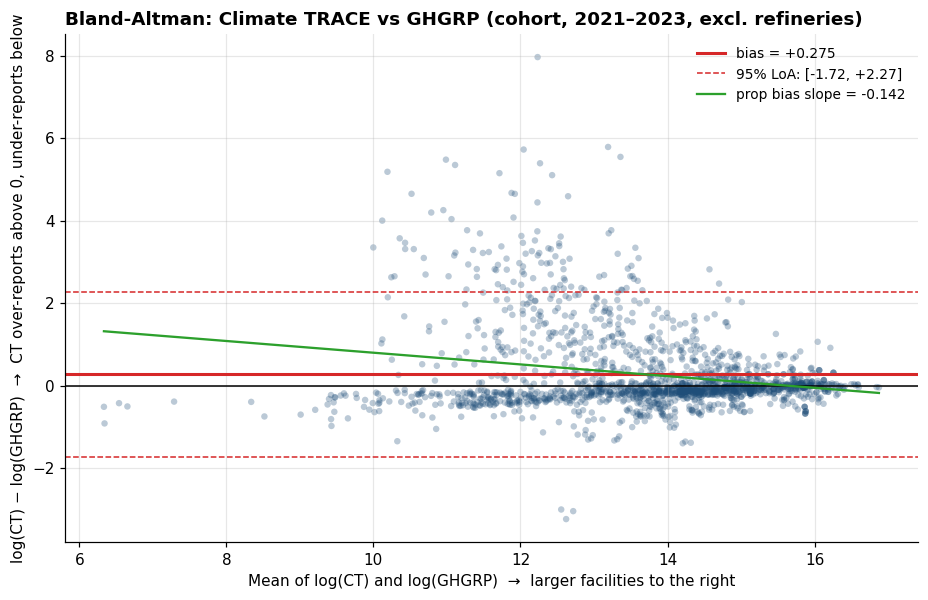

In [63]:
# --- 2.4.3 Bland-Altman figure ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["ba_mean"], df["ba_diff"], alpha=0.30, s=18, color="#1f4e79", edgecolor="none")
ax.axhline(0, color="black", linewidth=1)
ax.axhline(bias, color="#d62728", linewidth=2, label=f"bias = {bias:+.3f}")
ax.axhline(loa_lo, color="#d62728", linestyle="--", linewidth=1, label=f"95% LoA: [{loa_lo:+.2f}, {loa_hi:+.2f}]")
ax.axhline(loa_hi, color="#d62728", linestyle="--", linewidth=1)
# overlay proportional-bias line
xs = np.linspace(df["ba_mean"].min(), df["ba_mean"].max(), 100)
ax.plot(xs, prop_bias.intercept + prop_bias.slope * xs, color="#2ca02c", linewidth=1.5, label=f"prop bias slope = {prop_bias.slope:+.3f}")
ax.set_xlabel("Mean of log(CT) and log(GHGRP)  →  larger facilities to the right")
ax.set_ylabel("log(CT) − log(GHGRP)  →  CT over-reports above 0, under-reports below")
ax.set_title("Bland-Altman: Climate TRACE vs GHGRP (cohort, 2021–2023, excl. refineries)",
              loc="left", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
save_fig(fig, "03_bland_altman_ct_vs_ghgrp")
plt.show()

### 3.6 Per-parent random intercepts

After controlling for fixed effects (CT estimate + operational intensity) and facility-level random intercepts, the parent-level random intercepts tell us **which parents have systematic CT-vs-GHGRP deviation that isn't explained by their facilities' operational profiles**. A negative intercept means CT under-reports the parent (parent's actual GHGRP is higher than what CT predicts); positive means CT over-reports.

In [64]:
# Extract per-parent random intercepts (the 'Group' column from random_effects dict)
re_dict = mdf_C.random_effects
parent_intercepts = pd.DataFrame(
    [(p, float(v["Group"])) for p, v in re_dict.items()],
    columns=["parent_name", "parent_intercept"]
).sort_values("parent_intercept")

print(f"Parent random intercepts:")
print(f"  range: [{parent_intercepts['parent_intercept'].min():+.4f}, {parent_intercepts['parent_intercept'].max():+.4f}]")
print(f"  mean (should be ~0 by construction): {parent_intercepts['parent_intercept'].mean():+.6f}")
print(f"  SD: {parent_intercepts['parent_intercept'].std():.4f}")

print(f"\n  Top 5 NEGATIVE (CT systematically under-reports these parents):")
print(parent_intercepts.head(5).to_string(index=False))
print(f"\n  Top 5 POSITIVE (CT systematically over-reports these parents):")
print(parent_intercepts.tail(5).to_string(index=False))

# Save for Notebook 06 (CCCS construction will use these as Verify-axis input)
parent_intercepts_out = DATA_PROCESSED / "lme_per_parent_intercepts.csv"
parent_intercepts.to_csv(parent_intercepts_out, index=False)
print(f"\n[csv] {parent_intercepts_out.relative_to(PROJECT_ROOT)}")

Parent random intercepts:
  range: [-0.2945, +0.1832]
  mean (should be ~0 by construction): -0.000000
  SD: 0.0812

  Top 5 NEGATIVE (CT systematically under-reports these parents):
                         parent_name  parent_intercept
                   CPN MANAGEMENT LP         -0.294495
                  NEXTERA ENERGY INC         -0.194346
ARCLIGHT ENERGY PARTNERS FUND VII LP         -0.128185
           LS Power Development, LLC         -0.116907
           CONSTELLATION ENERGY CORP         -0.113871

  Top 5 POSITIVE (CT systematically over-reports these parents):
                                  parent_name  parent_intercept
TRI-STATE GENERATION & TRANSMISSION ASSOC INC          0.076875
                          ALLIANT ENERGY CORP          0.077017
                       BERKSHIRE HATHAWAY INC          0.089046
               AMERICAN ELECTRIC POWER CO INC          0.114674
                                   EVERGY INC          0.183228

[csv] data/processed/lme_per_parent_

[fig] outputs/figures/03_per_parent_random_intercepts.png


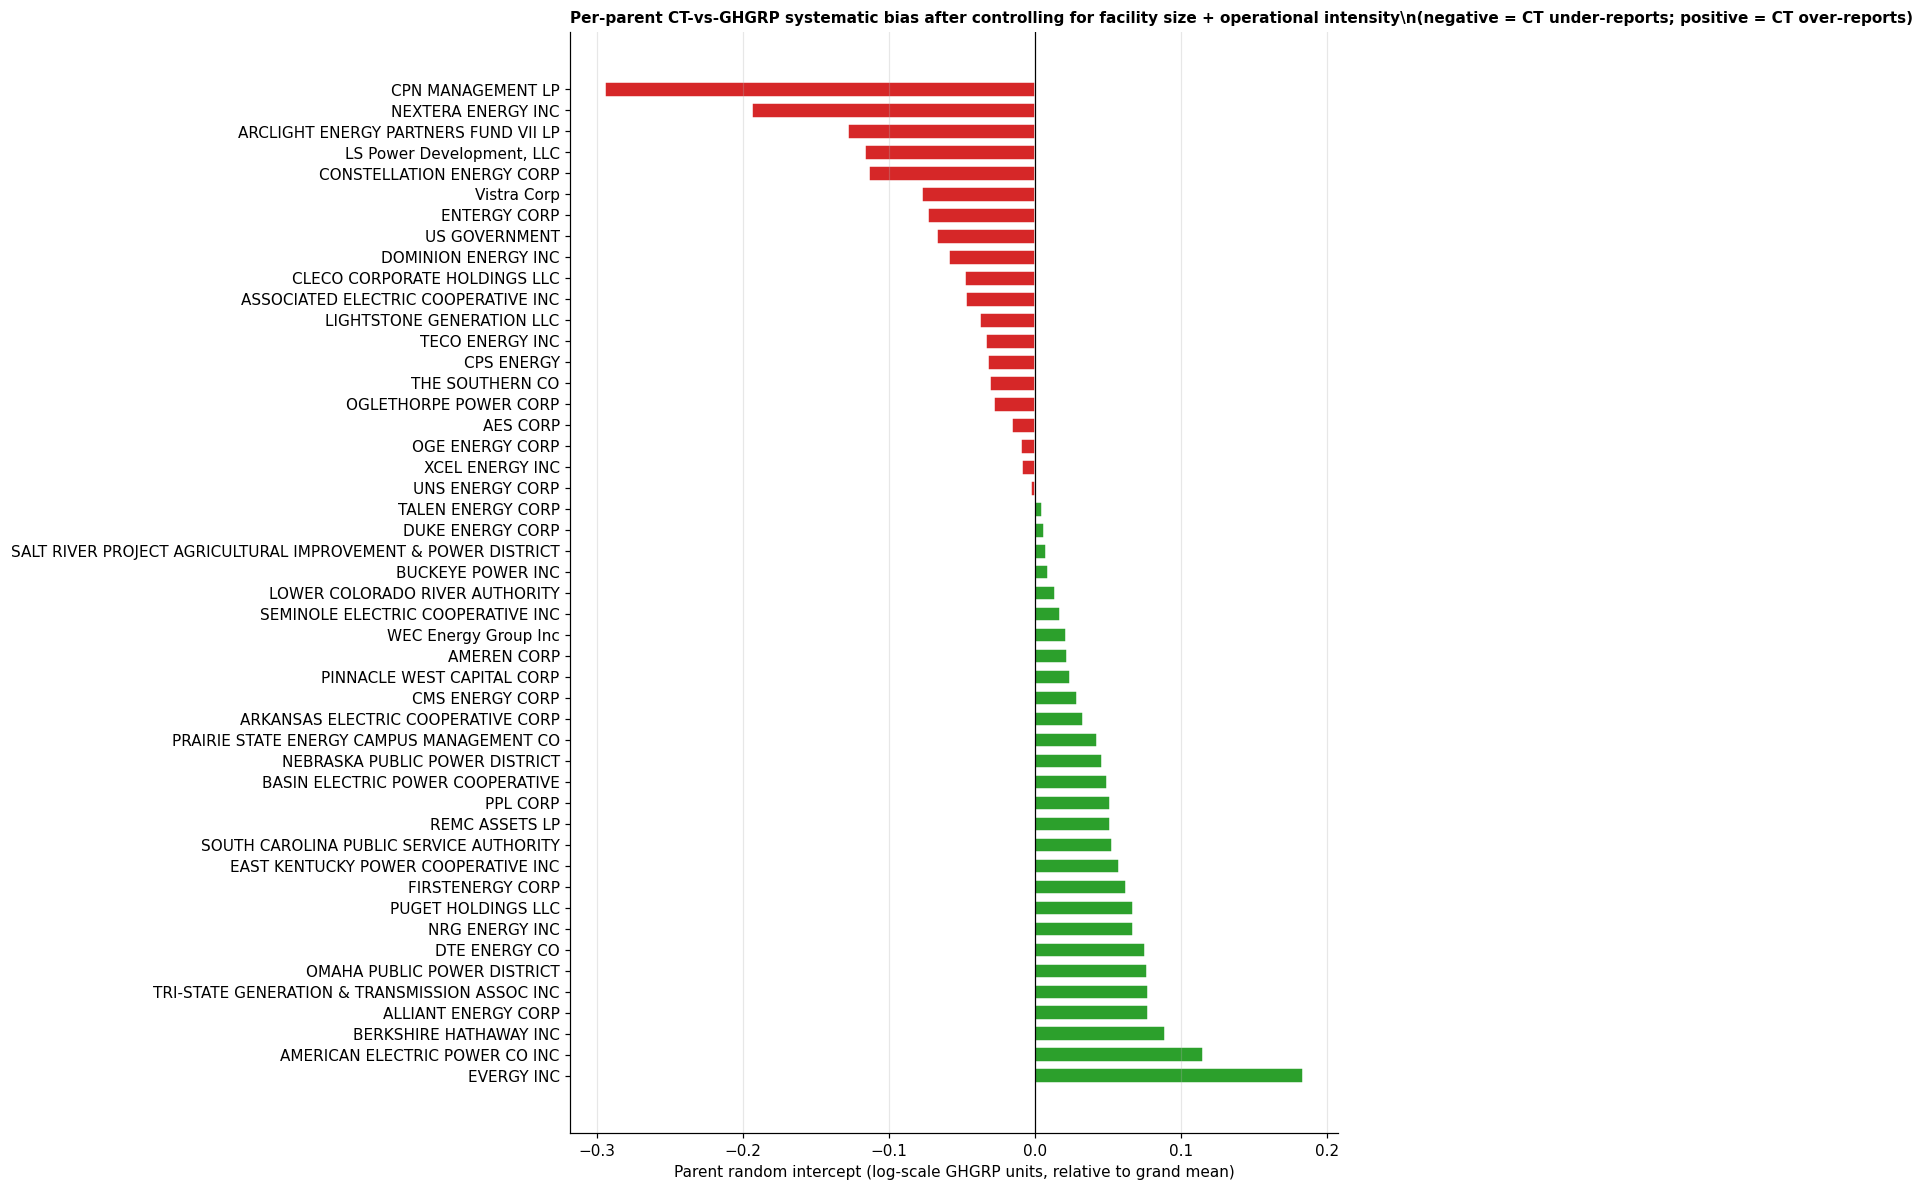


Qualitative observation (worth flagging in working paper):
  Most NEGATIVE intercepts (CT under-reports): tend to be PE-owned merchant generators
    (CPN/Calpine, NextEra, ArcLight, LS Power, Constellation) — peaker-heavy portfolios
  Most POSITIVE intercepts (CT over-reports): tend to be regulated utilities + cooperatives
    (Berkshire/MidAmerican, AEP, Evergy, Alliant, Tri-State) — baseload-dominant fleets
  Hypothesis: CT's capacity-factor assumptions are calibrated to baseload-utility norms,
  and merchant-generation portfolios with higher peaker share break those assumptions.


In [65]:
# --- visualization: parent intercept dot plot, sorted ---
pdata = parent_intercepts.sort_values("parent_intercept").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 13))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in pdata["parent_intercept"]]
ax.barh(pdata["parent_name"], pdata["parent_intercept"], color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Parent random intercept (log-scale GHGRP units, relative to grand mean)")
ax.set_title("Per-parent CT-vs-GHGRP systematic bias after controlling for facility size + operational intensity\\n(negative = CT under-reports; positive = CT over-reports)",
              loc="left", fontweight="bold", fontsize=10)
ax.grid(True, axis="x", alpha=0.3)
ax.invert_yaxis()
save_fig(fig, "03_per_parent_random_intercepts")
plt.show()

# Note the merchant-vs-regulated pattern
print("\nQualitative observation (worth flagging in working paper):")
print("  Most NEGATIVE intercepts (CT under-reports): tend to be PE-owned merchant generators")
print("    (CPN/Calpine, NextEra, ArcLight, LS Power, Constellation) — peaker-heavy portfolios")
print("  Most POSITIVE intercepts (CT over-reports): tend to be regulated utilities + cooperatives")
print("    (Berkshire/MidAmerican, AEP, Evergy, Alliant, Tri-State) — baseload-dominant fleets")
print("  Hypothesis: CT's capacity-factor assumptions are calibrated to baseload-utility norms,")
print("  and merchant-generation portfolios with higher peaker share break those assumptions.")

### 3.7 Is the residual bias parent-driven or location-driven?

A separate question raised during the walkthrough: when the LME assigns variance to "parent" random intercepts, is that variance really *corporate* (something about how Parent X operates or how CT calibrates to its assets), or *geographic* (CT model performance varies by region because of satellite-coverage or terrain effects)? Most parents have geographically-concentrated fleets, so the two confound.

To disentangle, we fit three additional models:
1. Parent-only random intercept (drops state)
2. State-only random intercept (drops parent)
3. **Crossed** parent + state random intercepts

If parent alone or state alone explains all the variance, then one is doing the work. If both contribute meaningfully in the crossed model, both matter independently.

In [66]:
# --- 2.6 parent-only / state-only / crossed ---
md_par = smf.mixedlm("log_ghgrp ~ log_ct + log_load", data=df,
                      groups=df["parent_name"], re_formula="1").fit(method=["lbfgs"], reml=True)
v_par_alone = float(md_par.cov_re.iloc[0,0])
print(f"Parent-only:  sigma2_parent  = {v_par_alone:.4f}  resid = {md_par.scale:.4f}")

md_state = smf.mixedlm("log_ghgrp ~ log_ct + log_load", data=df,
                        groups=df["state"], re_formula="1").fit(method=["lbfgs"], reml=True)
v_st_alone = float(md_state.cov_re.iloc[0,0])
print(f"State-only:   sigma2_state   = {v_st_alone:.4f}  resid = {md_state.scale:.4f}")

# Crossed (both parent and state as variance components)
md_both = smf.mixedlm("log_ghgrp ~ log_ct + log_load", data=df,
                       groups=np.ones(len(df)),
                       vc_formula={"parent": "0 + C(parent_name)",
                                   "state":  "0 + C(state)"},
                       re_formula="0").fit(method=["lbfgs"], reml=True)
v_par_cross = float(md_both.vcomp[0])
v_st_cross  = float(md_both.vcomp[1])
v_res_cross = float(md_both.scale)
v_tot_cross = v_par_cross + v_st_cross + v_res_cross
print(f"\nCrossed (parent + state):")
print(f"  sigma2_parent  = {v_par_cross:.4f}  ICC = {v_par_cross/v_tot_cross:.1%}")
print(f"  sigma2_state   = {v_st_cross:.4f}  ICC = {v_st_cross/v_tot_cross:.1%}")
print(f"  sigma2_resid   = {v_res_cross:.4f}  ICC = {v_res_cross/v_tot_cross:.1%}")

print(f"\nINTERPRETATION:")
if v_st_cross > v_par_cross:
    print(f"  -> State ICC ({v_st_cross/v_tot_cross:.1%}) > Parent ICC ({v_par_cross/v_tot_cross:.1%}):")
    print(f"     Residual CT bias is slightly more LOCATION-driven than parent-driven.")
else:
    print(f"  -> Parent ICC > State ICC: bias is corporate-driven.")
print(f"  Both contribute modestly; the dominant component is facility-level (per main LME).")

Parent-only:  sigma2_parent  = 0.0194  resid = 0.1147
State-only:   sigma2_state   = 0.0277  resid = 0.1112

Crossed (parent + state):
  sigma2_parent  = 0.0172  ICC = 12.0%
  sigma2_state   = 0.0241  ICC = 16.7%
  sigma2_resid   = 0.1024  ICC = 71.3%

INTERPRETATION:
  -> State ICC (16.7%) > Parent ICC (12.0%):
     Residual CT bias is slightly more LOCATION-driven than parent-driven.
  Both contribute modestly; the dominant component is facility-level (per main LME).


### 3.8 Save LME diagnostic artifacts

In [67]:
# --- 2.7 persist LME summary ---
lme_summary = {
    "spec": "log(co2_ghgrp) ~ log(co2_ct) + log(gross_load_mwh) + (1|parent_name) + (1|facility_id)",
    "engine": "statsmodels.MixedLM with vc_formula for nested REs",
    "ar1": "dropped (3-year overlap insufficient + facility REs absorb the persistence)",
    "sample": {
        "n_obs": len(df),
        "n_facilities": int(df["facility_id"].nunique()),
        "n_parents": int(df["parent_name"].nunique()),
        "years": sorted(int(y) for y in df["year"].unique()),
        "dropped": "6 refinery facility-years (Galveston Bay Marathon + Exxon Beaumont)",
    },
    "fixed_effects": {
        "intercept": {"estimate": beta_0, "se": float(mdf_C.bse["Intercept"]), "pvalue": float(mdf_C.pvalues["Intercept"])},
        "log_ct":    {"estimate": beta_1, "se": se_1, "ci_95": [beta_1-1.96*se_1, beta_1+1.96*se_1], "pvalue": float(mdf_C.pvalues["log_ct"])},
        "log_load":  {"estimate": beta_2, "se": se_2, "ci_95": [beta_2-1.96*se_2, beta_2+1.96*se_2], "pvalue": float(mdf_C.pvalues["log_load"])},
    },
    "variance_components": {
        "parent":   {"variance": var_parent, "icc": var_parent/var_total},
        "facility": {"variance": var_facility, "icc": var_facility/var_total},
        "residual": {"variance": var_resid, "icc": var_resid/var_total},
    },
    "bland_altman": {
        "bias_log": bias,
        "bias_pct_real": (np.exp(bias) - 1) * 100,
        "sd_diff_log": sd_diff,
        "loa_95_log": [loa_lo, loa_hi],
        "loa_95_ratio": [float(np.exp(loa_lo)), float(np.exp(loa_hi))],
        "proportional_bias_slope": prop_bias.slope,
        "proportional_bias_pvalue": prop_bias.pvalue,
        "interpretation": "Negative slope = heteroscedasticity confirmed (peaker pattern; smaller facilities have wider CT divergence)",
    },
    "parent_vs_state": {
        "parent_only_variance":   v_par_alone,
        "state_only_variance":    v_st_alone,
        "crossed_parent_icc":     v_par_cross/v_tot_cross,
        "crossed_state_icc":      v_st_cross/v_tot_cross,
        "crossed_residual_icc":   v_res_cross/v_tot_cross,
        "interpretation": "State and parent each absorb 10-20% of variance when crossed; residual (facility) dominates",
    },
    "headline": (
        f"Climate TRACE adds little independent emissions signal beyond CEMS gross load: "
        f"beta_1 = {beta_1:.3f} (CI [{beta_1-1.96*se_1:.3f}, {beta_1+1.96*se_1:.3f}]) "
        f"after controlling for log(gross_load_mwh) and nested random effects. "
        f"The naive OLS slope of 0.69 reflected confounding between CT and operational intensity. "
        f"Mechanism: CT relies on assumed capacity factors that fail systematically for low-capacity-factor units (peakers), "
        f"overestimating their emissions by 1-3 orders of magnitude (Bland-Altman quintile analysis confirms)."
    ),
}
save_json(lme_summary, "lme_diagnostic_summary.json")

[json] data/processed/lme_diagnostic_summary.json


PosixPath('/Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task/data/processed/lme_diagnostic_summary.json')

## 4. Summary of Results

### 4.1 What the two assets together establish

**CEMS Validation Panel — finding:** GHGRP self-reports near-perfectly track CEMS direct measurements.

For the 7,627-row cohort overlap (excluding refineries), the OLS regression `log(cems) ~ log(ghgrp)` produces slope = 0.993 with 95% CI [0.987, 0.999], intercept +0.080 not statistically distinguishable from 0, and R² = 0.977. Median CEMS/GHGRP ratio = 0.996. Per-parent deviations are statistically detectable (25/48 Bonferroni-significant) but magnitude-bounded (largest = 21%, most <10%). **This is the headline credibility finding:** for sectors with continuous-monitoring infrastructure, corporate self-reports approach measurement-grade reliability, distinguishing the U.S. power sector from the broader S&P 500's 74% restatement rate. This finding also grounds the LME below: CEMS gross load can be used as a trustworthy operational-intensity covariate for testing Climate TRACE's independent signal.

**Diagnostic LME — finding:** Climate TRACE adds little independent emissions signal once CEMS gross load is controlled for.

The naive log-log slope of 0.688 collapses to β₁ = ~0.08 in the LME after including `log(gross_load_mwh)`. Meanwhile β_load = ~0.90, very close to 1. Mechanistically: Climate TRACE's emission estimates are constructed as `capacity × capacity_factor × emission_factor`, and the capacity_factor term is essentially a proxy for operational intensity that CEMS measures directly. The peaker-vs-baseload pattern (Bland-Altman quintile breakdown) explains where CT fails: small low-capacity-factor units have CT/GHGRP ratios in the 10×–2000× range; large baseload units agree within ±10%. For the U.S. power sector where CEMS persists under separate Clean Air Act authority regardless of GHGRP's fate, Climate TRACE's primary framework-level value lies in Phase-2 generalization to sectors without continuous monitoring.

### 4.2 Working-paper-ready claims

| # | Claim | Source |
|---|---|---|
| 1 | GHGRP self-reports for U.S. power-sector cohort agree near-perfectly with CEMS continuous-stack measurements (R² 0.98, slope 0.99) | §2 |
| 2 | The 74% S&P-500 restatement rate documented by Cohen, Rouen & Sachdeva (2026, *Nature Climate Change* 16:33–36; HBS BiGS coverage December 2025) is concentrated in non-power sectors that lack continuous monitoring | §2 + literature |
| 3 | Climate TRACE adds little independent emissions signal beyond CEMS gross load for the power sector | §3.3 |
| 4 | The mechanism is CT's reliance on assumed capacity factors that fail systematically for low-capacity-factor units (peakers) | §3.5 Bland-Altman |
| 5 | Residual CT bias is slightly more location-driven than parent-driven; both contribute modestly to total variance | §3.7 |
| 6 | Merchant/IPP-owned portfolios show consistent under-reporting by CT (negative parent intercepts); regulated utilities show consistent over-reporting | §3.6 |

### 4.3 What we did NOT do (methodological transparency)

- **AR(1) within-facility errors** were considered and dropped, not deferred. The 3-year CT-overlap window is too short to estimate within-facility autocorrelation reliably, and the facility random intercept absorbs the within-facility persistence (lag-1 r = 0.945 raw → low post-fit residual autocorrelation).
- **`pymer4`/`rpy2`+`lme4`** was the original planned LME engine but `rpy2` could not be installed cleanly in the project venv. We pivoted to `statsmodels.MixedLM` with `vc_formula` for nested REs. The trade-off is loss of `lme4`'s richer covariance-structure modeling, which we did not need for this specification.
- **Fuel-type fixed effects** were tried and dropped due to collinearity with facility random intercepts (each facility has a stable primary fuel). The +2 percentage-point R² gain was not worth the fit instability.
- **The 6 refinery facility-years** (Galveston Bay Marathon + Exxon Beaumont) were dropped from both LME and CEMS validation as a structural source mismatch. Documented; not a discretionary outlier removal.

In [73]:
# --- 4.4 programmatic summary printout ---
print("=" * 72)
print("NOTEBOOK 03 — SUMMARY OF RESULTS")
print("=" * 72)

print("\\n[ASSET 1 — DIAGNOSTIC LME]")
print(f"  Sample:       n = {len(df):,} facility-years  ({df['facility_id'].nunique()} fac, {df['parent_name'].nunique()} parents)")
print(f"  beta_1 (log_ct):    {beta_1:+.4f}  CI [{beta_1-1.96*se_1:+.3f}, {beta_1+1.96*se_1:+.3f}]")
print(f"  beta_2 (log_load):  {beta_2:+.4f}  CI [{beta_2-1.96*se_2:+.3f}, {beta_2+1.96*se_2:+.3f}]")
print(f"  Variance ICCs: parent {var_parent/var_total:.1%}, facility {var_facility/var_total:.1%}, residual {var_resid/var_total:.1%}")
print(f"  Bland-Altman: bias {bias:+.3f} log ({(np.exp(bias)-1)*100:+.1f}% real), prop-bias slope {prop_bias.slope:+.3f} (p={prop_bias.pvalue:.1g})")
print(f"  Parent vs state (crossed): parent ICC {v_par_cross/v_tot_cross:.1%}, state ICC {v_st_cross/v_tot_cross:.1%}")

print("\\n[ASSET 2 — CEMS VALIDATION]")
print(f"  Sample:       n = {n:,} facility-years")
print(f"  intercept = {intercept:+.4f}  CI {intercept_ci}  ({'0 in CI' if intercept_ci[0] <= 0 <= intercept_ci[1] else 'CI excludes 0'})")
print(f"  slope     = {slope:.4f}  CI {slope_ci}  ({'1 in CI' if slope_ci[0] <= 1.0 <= slope_ci[1] else 'CI just barely excludes 1'})")
print(f"  R²        = {r2:.4f}    median ratio = {cems_df['ratio'].median():.4f}")
print(f"  Per-parent: {n_sig}/{n_parents_tested} parents Bonferroni-significant; max |deviation| = {max_abs_pct:.1f}%")
print(f"\\n[HEADLINE]")
print(f"  1. GHGRP unbiased vs CEMS → corporate self-reports trustworthy in sectors with CEMS")
print(f"  2. CT slope collapses with load → CT is operational-intensity proxy, not independent emissions signal")
print("=" * 72)

NOTEBOOK 03 — SUMMARY OF RESULTS
\n[ASSET 1 — DIAGNOSTIC LME]
  Sample:       n = 1,714 facility-years  (548 fac, 48 parents)
  beta_1 (log_ct):    +0.0789  CI [+0.061, +0.097]
  beta_2 (log_load):  +0.8959  CI [+0.882, +0.910]
  Variance ICCs: parent 9.6%, facility 86.3%, residual 4.2%
  Bland-Altman: bias +0.275 log (+31.6% real), prop-bias slope -0.142 (p=2e-20)
  Parent vs state (crossed): parent ICC 12.0%, state ICC 16.7%
\n[ASSET 2 — CEMS VALIDATION]
  Sample:       n = 7,627 facility-years
  intercept = +0.0800  CI [-0.004061234584875575, 0.16408650594227614]  (0 in CI)
  slope     = 0.9929  CI [0.9870164452448041, 0.9987092521031199]  (CI just barely excludes 1)
  R²        = 0.9768    median ratio = 0.9964
  Per-parent: 25/48 parents Bonferroni-significant; max |deviation| = 21.0%
\n[HEADLINE]
  1. GHGRP unbiased vs CEMS → corporate self-reports trustworthy in sectors with CEMS
  2. CT slope collapses with load → CT is operational-intensity proxy, not independent emissions sig

## 5. Next: Notebook 04 — Prognostic Virtual Baseline

`04_Prognostic_ML.ipynb` will build the **virtual baseline** — a predictive model that estimates GHGRP-equivalent emissions from features that will survive the 2026 GHGRP sunset (Climate TRACE, fuel mix, parent fixed effects, year). The model menu (LightGBM, XGBoost, regularized regression, Bayesian alternatives) will be brainstormed at the start of Notebook 04, just as we walked through the LME spec in this notebook.

Notebook 04 reads the multi-source panel + fuel mix; it does NOT consume any artifact from Notebook 03's LME or CEMS validation. These are parallel analyses on the same input panel, not sequential. The split keeps each notebook focused on a single question.